# Global NorESM Susceptibility — Maps and Cluster Analysis

Global (lat/lon) CCN→CDNC susceptibility from NorESM, pre-computed per level and saved
under `/share/pech2273/susceptibility/`. This notebook (1) maps the global susceptibility
field, and (2) clusters the susceptibility-vs-diameter *profiles* to identify regional
aerosol regimes and their optimal CCN activation diameter.

## 1. Setup and load saved susceptibility

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment
from scipy.ndimage import gaussian_filter1d
from kneed import KneeLocator
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D


In [2]:
# Pre-computed susceptibility saved per level then combined (see compute pipeline on Tetralith).
#   susceptibility_all_levels.nc          : slope(lat, lon, radius, updraft_q)  -- vertically combined
#   susceptibility_all_levels_combined.nc : same with an explicit level/coordinate structure
SUSC_DIR = Path('/share/pech2273/susceptibility')
ds_combined   = xr.open_dataset(SUSC_DIR / 'susceptibility_all_levels_combined.nc')
ds_alllevels  = xr.open_dataset(SUSC_DIR / 'susceptibility_all_levels.nc')


## 2. Global susceptibility maps

Susceptibility at a 40 nm radius (80 nm diameter) cutoff, for the `Total` updraft band
and split across the four updraft quantile bands.

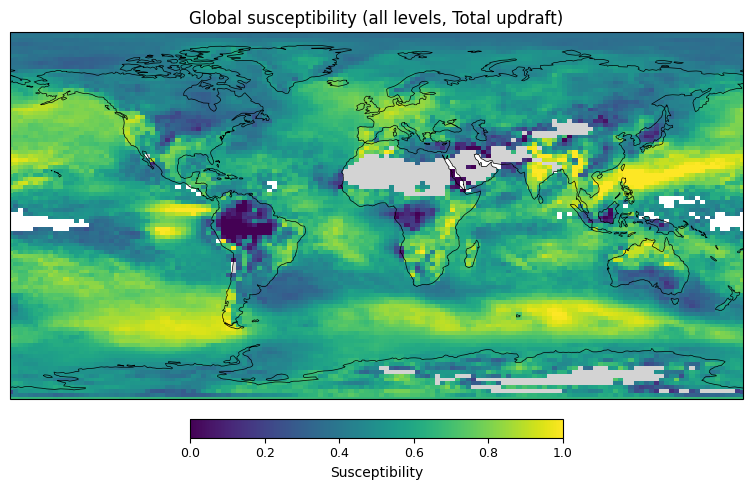

In [3]:
# --- Total susceptibility map (single panel) ---
graphing = ds_alllevels.slope.sel(radius=40, method='nearest').sel(updraft_q='Total')

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(graphing.lon.values, graphing.lat.values, graphing,
                   cmap='viridis', vmin=0, vmax=1, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.set_title('Global susceptibility (all levels, Total updraft)', fontsize=12)
cb = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, fraction=0.046,
                  label='Susceptibility')
cb.ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()


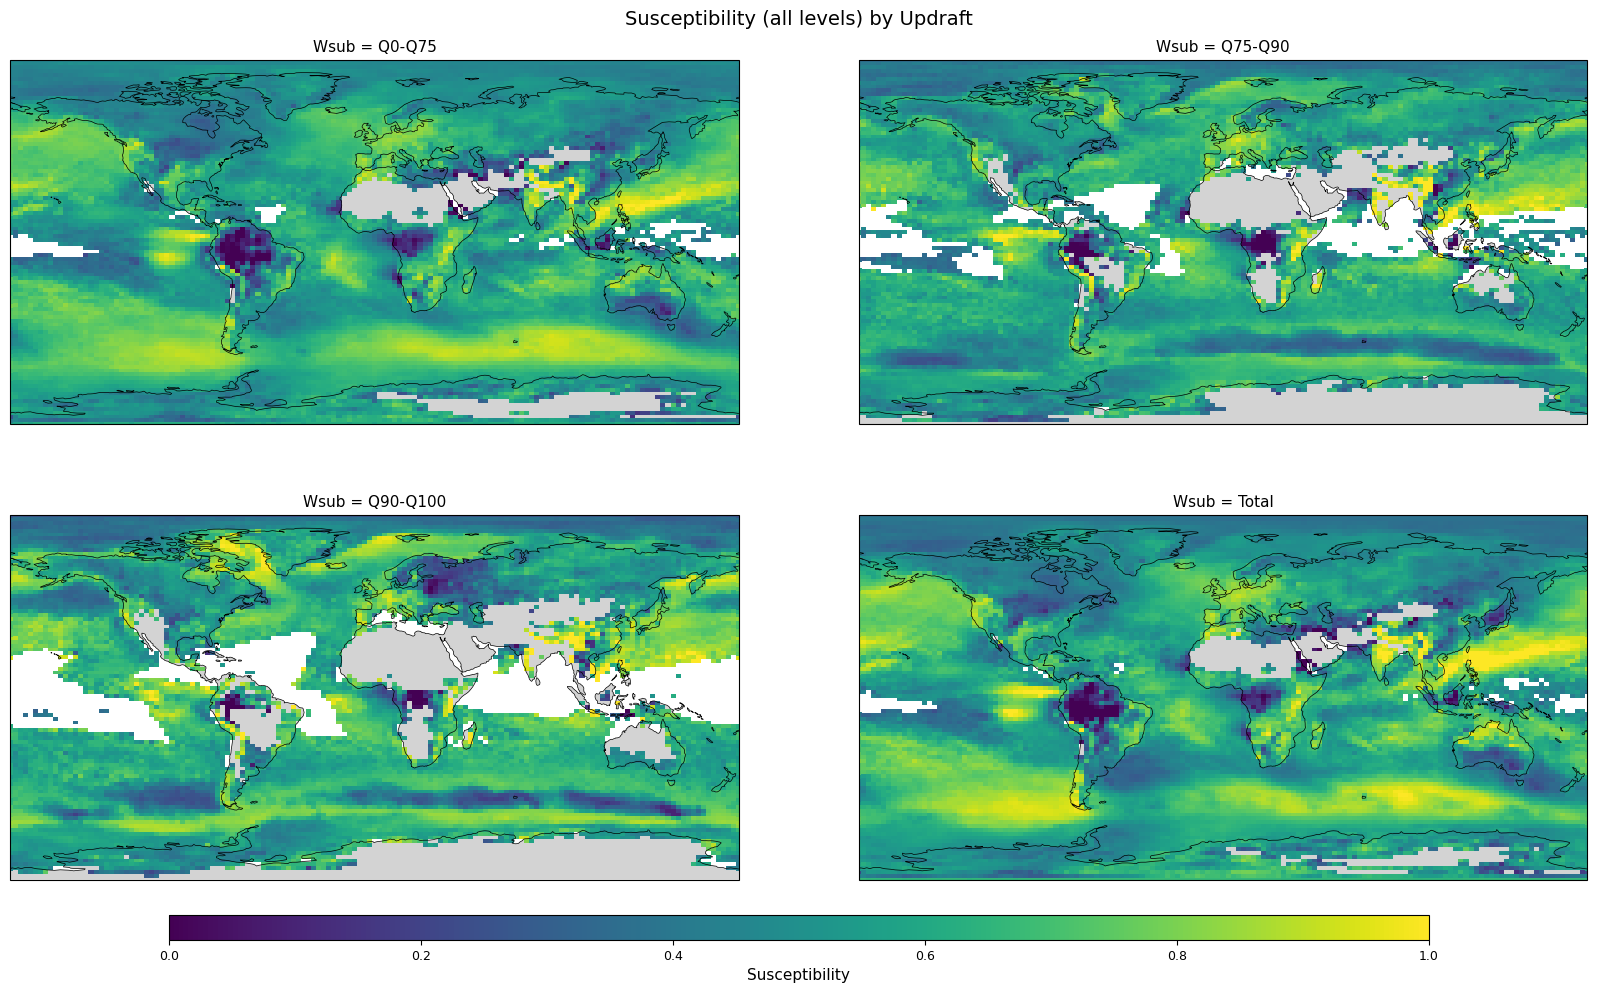

In [4]:
# --- Susceptibility by updraft band (2x2 panels, shared colorbar) ---
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.1, left=0.05, right=0.95, top=0.92, bottom=0.1)
updraft_vals = ds_alllevels.updraft_q.values
axes = [fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree())
        for i in range(2) for j in range(2)]

for ax, uq in zip(axes, updraft_vals):
    graphing = ds_alllevels.slope.sel(radius=40, method='nearest').sel(updraft_q=uq)
    im = ax.pcolormesh(graphing.lon.values, graphing.lat.values, graphing,
                       cmap='viridis', vmin=0, vmax=1, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax.set_title(f'Wsub = {uq}', fontsize=11)

cbar_ax = fig.add_axes([0.15, 0.04, 0.7, 0.025])
cb = plt.colorbar(im, cax=cbar_ax, orientation='horizontal')
cb.set_label('Susceptibility', fontsize=11)
cb.ax.tick_params(labelsize=9)
fig.suptitle('Susceptibility (all levels) by Updraft', fontsize=14, y=0.97)
plt.show()


## 3. K-means clustering of susceptibility profiles

Cluster each grid cell's susceptibility-vs-diameter profile (k=4) two ways and compare:

- **Method A — StandardScaler:** standardizes each radius *column* across grid points, so
  both the magnitude (overall susceptibility level) and the shape drive the clustering.
- **Method B — per-profile z-score:** standardizes each *profile* (row), removing level and
  amplitude so only the **shape** of the susceptibility curve matters.

Method B's labels are aligned to A's (Hungarian algorithm on spatial overlap) so the two
maps share a colour scheme.

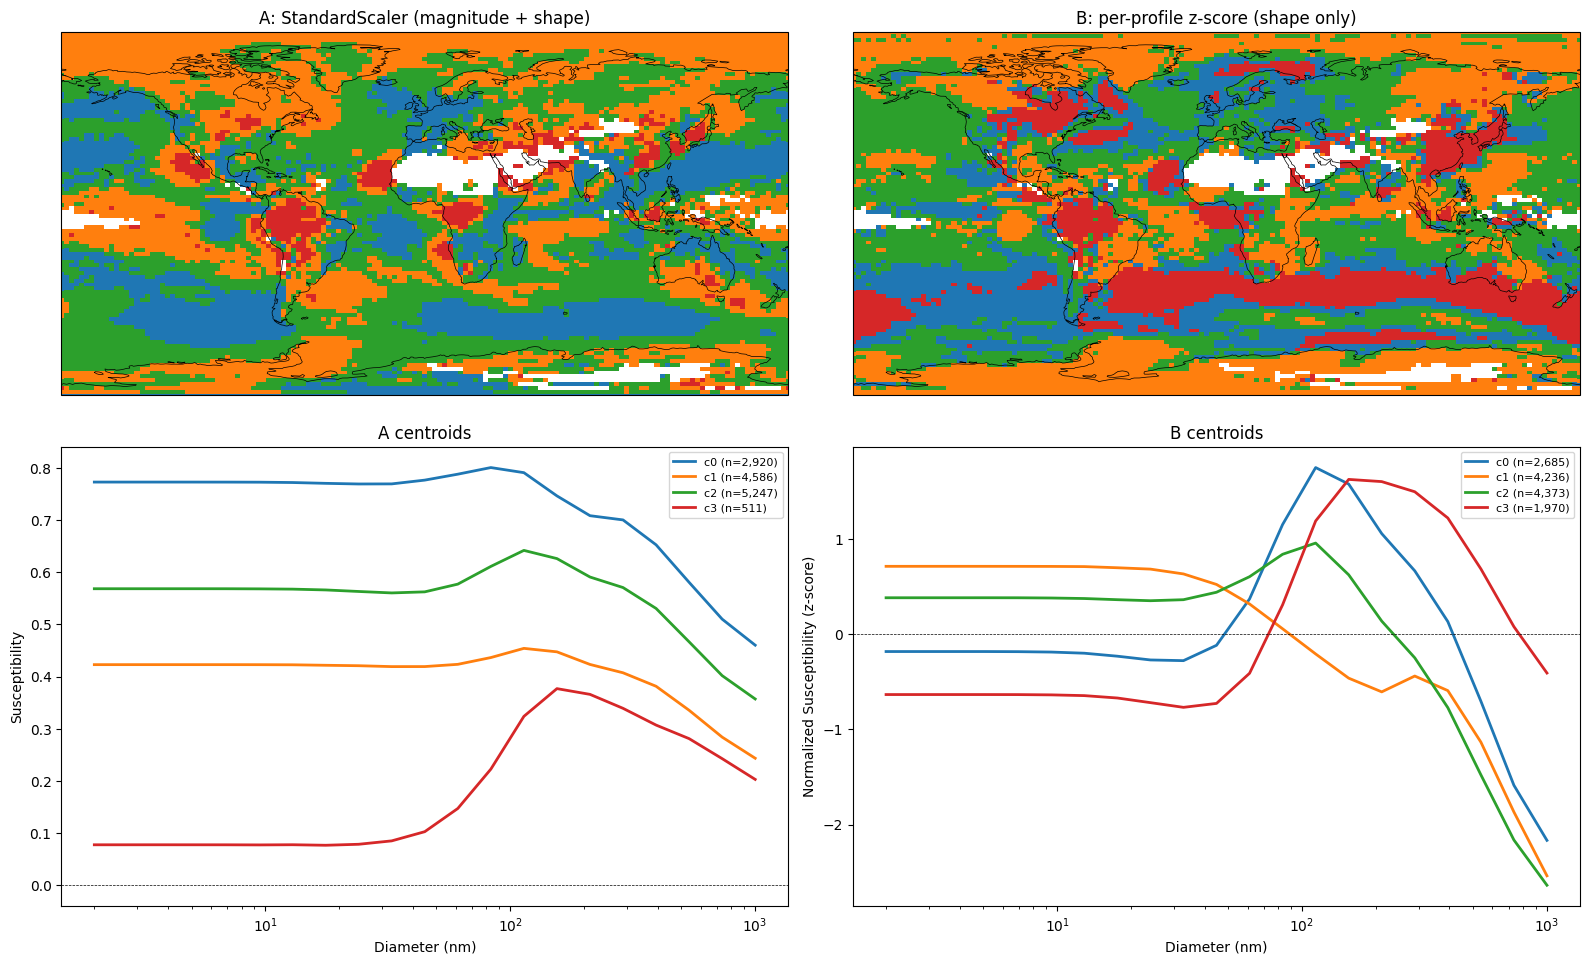

8,216 of 13,264 profiles (61.9%) changed cluster between methods


In [3]:
# --- Load susceptibility, stack profiles, run both clustering methods ---
# ── Load ──────────────────────────────────────────────────────
SUSC_DIR = Path('/share/pech2273/susceptibility')
ds = xr.open_dataset(SUSC_DIR / 'susceptibility_all_levels.nc')
X = ds.slope.sel(updraft_q='Total')          # (lat, lon, radius)
lat, lon, radius = X['lat'].values, X['lon'].values, X['radius'].values

k = 4   # use the same k for both so the comparison is fair

# ── Stack to (n_profiles, radius) and find valid rows ─────────
X_stacked = X.stack(sample=('lat', 'lon')).transpose('sample', 'radius')
vals = X_stacked.values                       # (n_profiles, 21)
valid = ~np.isnan(vals).any(axis=1)
vals_valid = vals[valid]

# ── Method A: StandardScaler (previous approach) ──────────────
# standardizes each radius COLUMN across grid points -> keeps per-profile level/amplitude
scaler = StandardScaler()
vals_scaledA = scaler.fit_transform(vals_valid)
kmA = KMeans(n_clusters=k, random_state=42, n_init=10)
labelsA = kmA.fit_predict(vals_scaledA)
centroidsA = scaler.inverse_transform(kmA.cluster_centers_)   # back to slope units

# ── Method B: per-profile z-score (shape-only) ────────────────
# standardizes each ROW (profile) -> removes level and amplitude
row_mean = vals_valid.mean(axis=1, keepdims=True)
row_std  = vals_valid.std(axis=1, keepdims=True)
vals_scaledB = (vals_valid - row_mean) / row_std
kmB = KMeans(n_clusters=k, random_state=42, n_init=10)
labelsB = kmB.fit_predict(vals_scaledB)
centroidsB = kmB.cluster_centers_              # already in z-score units

# ── Align B's cluster labels to A's for comparable colors ─────
# match clusters by spatial overlap (Hungarian on confusion matrix)
conf = np.zeros((k, k), dtype=int)
for a in range(k):
    for b in range(k):
        conf[a, b] = np.sum((labelsA == a) & (labelsB == b))
row_ind, col_ind = linear_sum_assignment(-conf)   # maximize overlap
remap = {old: new for new, old in zip(row_ind, col_ind)}
labelsB_aligned = np.array([remap[l] for l in labelsB])
inv_remap = {new: old for old, new in remap.items()}

# ── Put labels back on the (lat, lon) grid ────────────────────
def to_grid(labels_valid):
    full = np.full(vals.shape[0], -1)
    full[valid] = labels_valid
    da = xr.DataArray(full, dims='sample',
                      coords={'sample': X_stacked['sample']}).unstack('sample')
    return da

mapA = to_grid(labelsA)
mapB = to_grid(labelsB_aligned)
mapA_plot = mapA.where(mapA >= 0)   # -1 (empty cells) -> NaN -> not drawn
mapB_plot = mapB.where(mapB >= 0)

# ── Figure: 2 maps + 2 centroid panels ────────────────────────
fig = plt.figure(figsize=(16, 10))
cmap = plt.get_cmap('tab10')

# discrete colormap so cluster i -> cmap(i) on the maps too (matches centroids)
cluster_cmap = ListedColormap([cmap(i) for i in range(k)])
norm = BoundaryNorm(np.arange(-0.5, k, 1), cluster_cmap.N)

# Map A
axA = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
imA = axA.pcolormesh(mapA_plot['lon'], mapA_plot['lat'], mapA_plot.values,
                     cmap=cluster_cmap, norm=norm,
                     transform=ccrs.PlateCarree(), shading='nearest')
axA.add_feature(cfeature.COASTLINE, linewidth=0.5)
axA.set_global(); axA.set_title('A: StandardScaler (magnitude + shape)')

# Map B
axB = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
imB = axB.pcolormesh(mapB_plot['lon'], mapB_plot['lat'], mapB_plot.values,
                     cmap=cluster_cmap, norm=norm,
                     transform=ccrs.PlateCarree(), shading='nearest')
axB.add_feature(cfeature.COASTLINE, linewidth=0.5)
axB.set_global(); axB.set_title('B: per-profile z-score (shape only)')

# Centroids A (original slope units)
axCA = fig.add_subplot(2, 2, 3)
for i in range(k):
    n = np.sum(labelsA == i)
    axCA.plot(radius*2, centroidsA[i], color=cmap(i), lw=2, label=f'c{i} (n={n:,})')
axCA.set_xscale('log'); axCA.axhline(0, color='k', lw=0.5, ls='--')
axCA.set_xlabel('Diameter (nm)'); axCA.set_ylabel('Susceptibility')
axCA.set_title('A centroids'); axCA.legend(fontsize=8)

# Centroids B (z-score units, colors aligned to A)
axCB = fig.add_subplot(2, 2, 4)
for i in range(k):
    orig = inv_remap[i]
    n = np.sum(labelsB_aligned == i)
    axCB.plot(radius*2, centroidsB[orig], color=cmap(i), lw=2, label=f'c{i} (n={n:,})')
axCB.set_xscale('log'); axCB.axhline(0, color='k', lw=0.5, ls='--')
axCB.set_xlabel('Diameter (nm)'); axCB.set_ylabel('Normalized Susceptibility (z-score)')
axCB.set_title('B centroids'); axCB.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Quick numeric summary of how much moved ───────────────────
moved = np.sum(labelsA != labelsB_aligned)
print(f"{moved:,} of {len(labelsA):,} profiles "
      f"({100*moved/len(labelsA):.1f}%) changed cluster between methods")

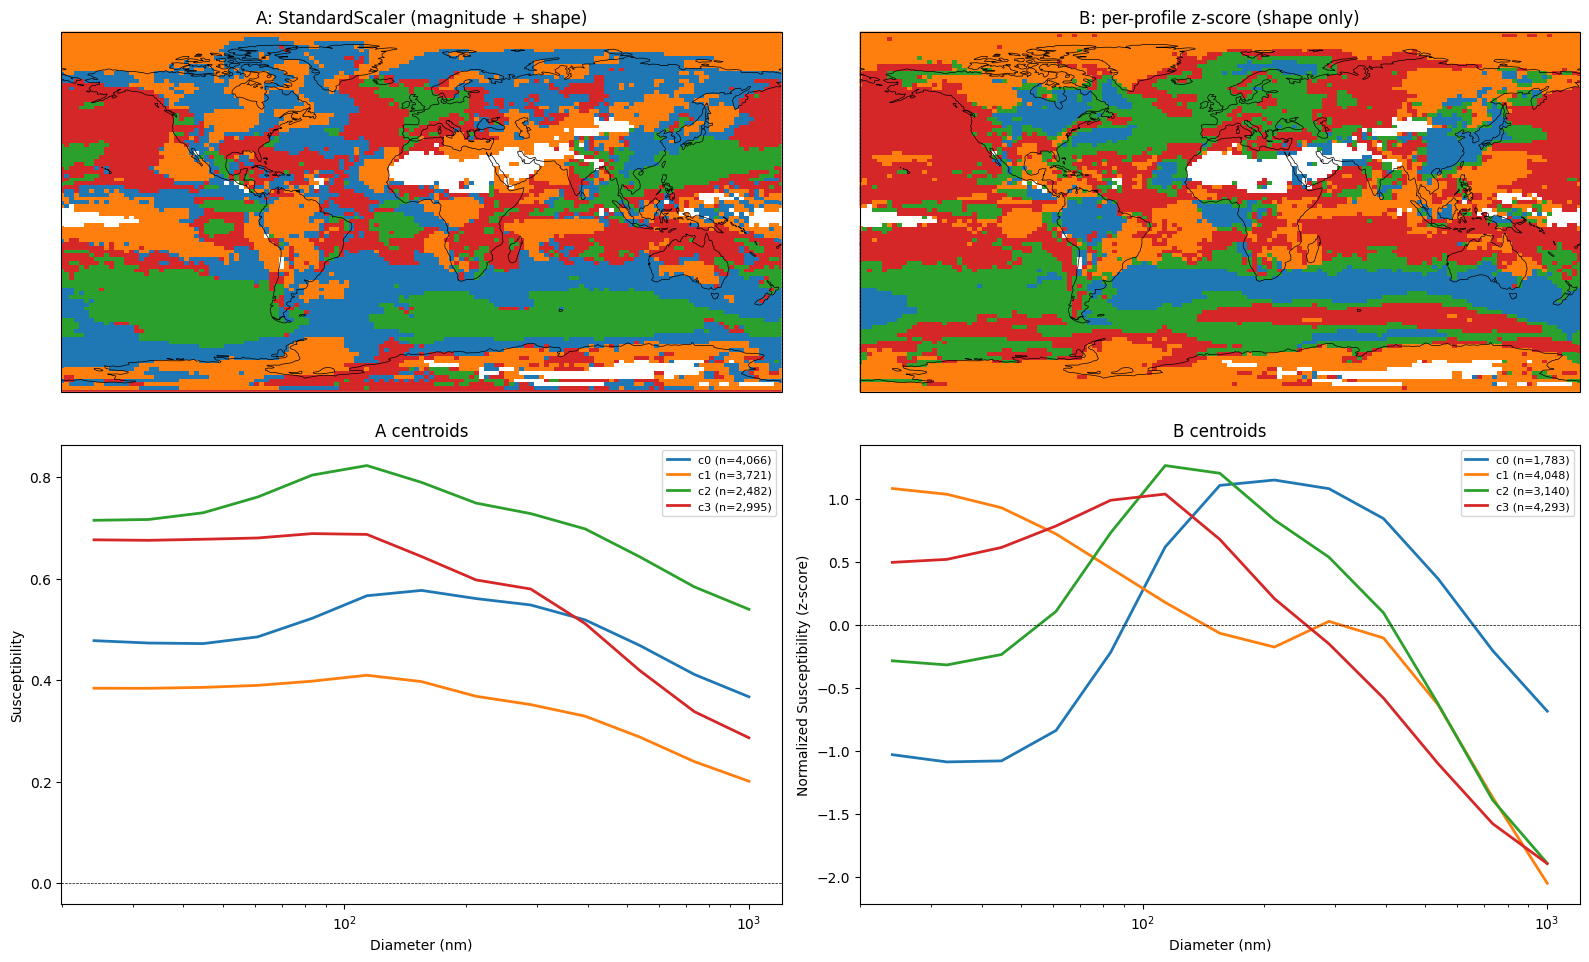

7,565 of 13,264 profiles (57.0%) changed cluster between methods


In [6]:
# --- Load susceptibility, stack profiles, run both clustering methods ---
# ── Load ──────────────────────────────────────────────────────
SUSC_DIR = Path('/share/pech2273/susceptibility')
ds = xr.open_dataset(SUSC_DIR / 'susceptibility_all_levels.nc')
X = ds.slope.sel(updraft_q='Total').isel(radius = slice(8, 21))          # (lat, lon, radius)
lat, lon, radius = X['lat'].values, X['lon'].values, X['radius'].values

k = 4   # use the same k for both so the comparison is fair

# ── Stack to (n_profiles, radius) and find valid rows ─────────
X_stacked = X.stack(sample=('lat', 'lon')).transpose('sample', 'radius')
vals = X_stacked.values                       # (n_profiles, 21)
valid = ~np.isnan(vals).any(axis=1)
vals_valid = vals[valid]

# ── Method A: StandardScaler (previous approach) ──────────────
# standardizes each radius COLUMN across grid points -> keeps per-profile level/amplitude
scaler = StandardScaler()
vals_scaledA = scaler.fit_transform(vals_valid)
kmA = KMeans(n_clusters=k, random_state=42, n_init=10)
labelsA = kmA.fit_predict(vals_scaledA)
centroidsA = scaler.inverse_transform(kmA.cluster_centers_)   # back to slope units

# ── Method B: per-profile z-score (shape-only) ────────────────
# standardizes each ROW (profile) -> removes level and amplitude
row_mean = vals_valid.mean(axis=1, keepdims=True)
row_std  = vals_valid.std(axis=1, keepdims=True)
vals_scaledB = (vals_valid - row_mean) / row_std
kmB = KMeans(n_clusters=k, random_state=42, n_init=10)
labelsB = kmB.fit_predict(vals_scaledB)
centroidsB = kmB.cluster_centers_              # already in z-score units

# ── Align B's cluster labels to A's for comparable colors ─────
# match clusters by spatial overlap (Hungarian on confusion matrix)
conf = np.zeros((k, k), dtype=int)
for a in range(k):
    for b in range(k):
        conf[a, b] = np.sum((labelsA == a) & (labelsB == b))
row_ind, col_ind = linear_sum_assignment(-conf)   # maximize overlap
remap = {old: new for new, old in zip(row_ind, col_ind)}
labelsB_aligned = np.array([remap[l] for l in labelsB])
inv_remap = {new: old for old, new in remap.items()}

# ── Put labels back on the (lat, lon) grid ────────────────────
def to_grid(labels_valid):
    full = np.full(vals.shape[0], -1)
    full[valid] = labels_valid
    da = xr.DataArray(full, dims='sample',
                      coords={'sample': X_stacked['sample']}).unstack('sample')
    return da

mapA = to_grid(labelsA)
mapB = to_grid(labelsB_aligned)
mapA_plot = mapA.where(mapA >= 0)   # -1 (empty cells) -> NaN -> not drawn
mapB_plot = mapB.where(mapB >= 0)

# ── Figure: 2 maps + 2 centroid panels ────────────────────────
fig = plt.figure(figsize=(16, 10))
cmap = plt.get_cmap('tab10')

# discrete colormap so cluster i -> cmap(i) on the maps too (matches centroids)
cluster_cmap = ListedColormap([cmap(i) for i in range(k)])
norm = BoundaryNorm(np.arange(-0.5, k, 1), cluster_cmap.N)

# Map A
axA = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
imA = axA.pcolormesh(mapA_plot['lon'], mapA_plot['lat'], mapA_plot.values,
                     cmap=cluster_cmap, norm=norm,
                     transform=ccrs.PlateCarree(), shading='nearest')
axA.add_feature(cfeature.COASTLINE, linewidth=0.5)
axA.set_global(); axA.set_title('A: StandardScaler (magnitude + shape)')

# Map B
axB = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
imB = axB.pcolormesh(mapB_plot['lon'], mapB_plot['lat'], mapB_plot.values,
                     cmap=cluster_cmap, norm=norm,
                     transform=ccrs.PlateCarree(), shading='nearest')
axB.add_feature(cfeature.COASTLINE, linewidth=0.5)
axB.set_global(); axB.set_title('B: per-profile z-score (shape only)')

# Centroids A (original slope units)
axCA = fig.add_subplot(2, 2, 3)
for i in range(k):
    n = np.sum(labelsA == i)
    axCA.plot(radius*2, centroidsA[i], color=cmap(i), lw=2, label=f'c{i} (n={n:,})')
axCA.set_xscale('log'); axCA.axhline(0, color='k', lw=0.5, ls='--')
axCA.set_xlabel('Diameter (nm)'); axCA.set_ylabel('Susceptibility')
axCA.set_title('A centroids'); axCA.legend(fontsize=8)

# Centroids B (z-score units, colors aligned to A)
axCB = fig.add_subplot(2, 2, 4)
for i in range(k):
    orig = inv_remap[i]
    n = np.sum(labelsB_aligned == i)
    axCB.plot(radius*2, centroidsB[orig], color=cmap(i), lw=2, label=f'c{i} (n={n:,})')
axCB.set_xscale('log'); axCB.axhline(0, color='k', lw=0.5, ls='--')
axCB.set_xlabel('Diameter (nm)'); axCB.set_ylabel('Normalized Susceptibility (z-score)')
axCB.set_title('B centroids'); axCB.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Quick numeric summary of how much moved ───────────────────
moved = np.sum(labelsA != labelsB_aligned)
print(f"{moved:,} of {len(labelsA):,} profiles "
      f"({100*moved/len(labelsA):.1f}%) changed cluster between methods")

Sanity check on excluded profiles (any/all NaN across radius).

In [6]:
n_any = np.isnan(vals).any(axis=1).sum()
n_all = np.isnan(vals).all(axis=1).sum()
print(f'profiles with any NaN: {n_any:,}   all NaN: {n_all:,}')


profiles with any NaN: 560   all NaN: 560


Effect of the two scalings on the raw profiles (level preserved vs shape-only).

/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


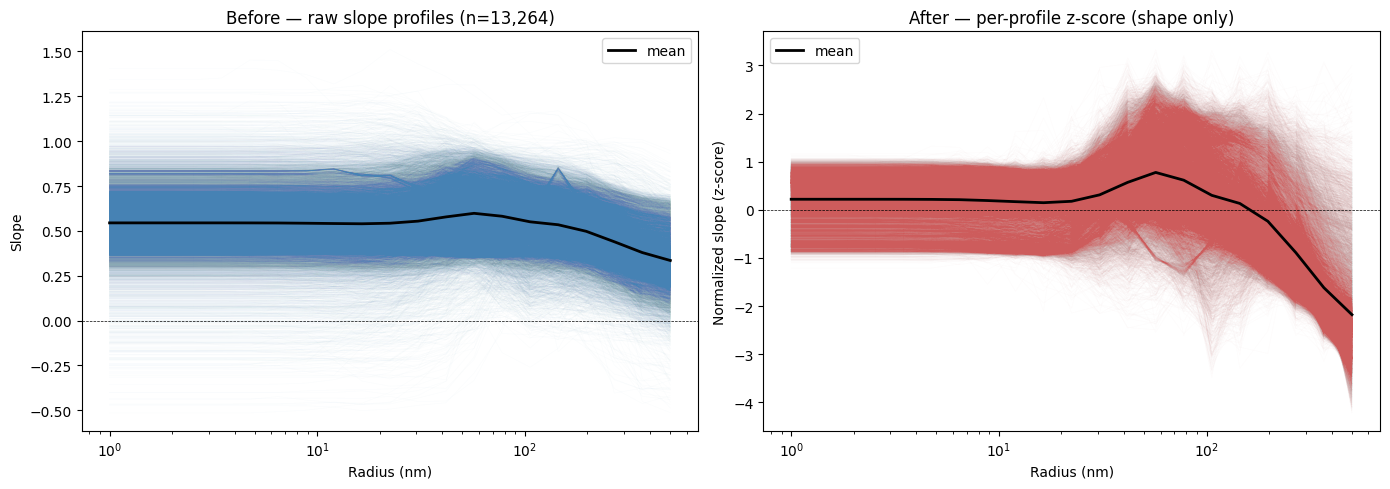

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# uses vals_valid (raw) and vals_scaledB (per-profile z-scored) from your cell
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Before: raw slope profiles ────────────────────────────────
ax1.plot(radius, vals_valid.T, color='steelblue', alpha=0.02, lw=0.5)
ax1.plot(radius, vals_valid.mean(axis=0), color='black', lw=2, label='mean')
ax1.set_xscale('log')
ax1.axhline(0, color='k', lw=0.5, ls='--')
ax1.set_xlabel('Radius (nm)'); ax1.set_ylabel('Slope')
ax1.set_title(f'Before — raw slope profiles (n={vals_valid.shape[0]:,})')
ax1.legend()

# ── After: per-profile z-scored profiles ──────────────────────
ax2.plot(radius, vals_scaledB.T, color='indianred', alpha=0.02, lw=0.5)
ax2.plot(radius, vals_scaledB.mean(axis=0), color='black', lw=2, label='mean')
ax2.set_xscale('log')
ax2.axhline(0, color='k', lw=0.5, ls='--')
ax2.set_xlabel('Radius (nm)'); ax2.set_ylabel('Normalized slope (z-score)')
ax2.set_title('After — per-profile z-score (shape only)')
ax2.legend()

plt.tight_layout()
plt.show()

Single-cell walk-through of what each scaling does to one profile (raw, StandardScaler,
per-profile z-score).

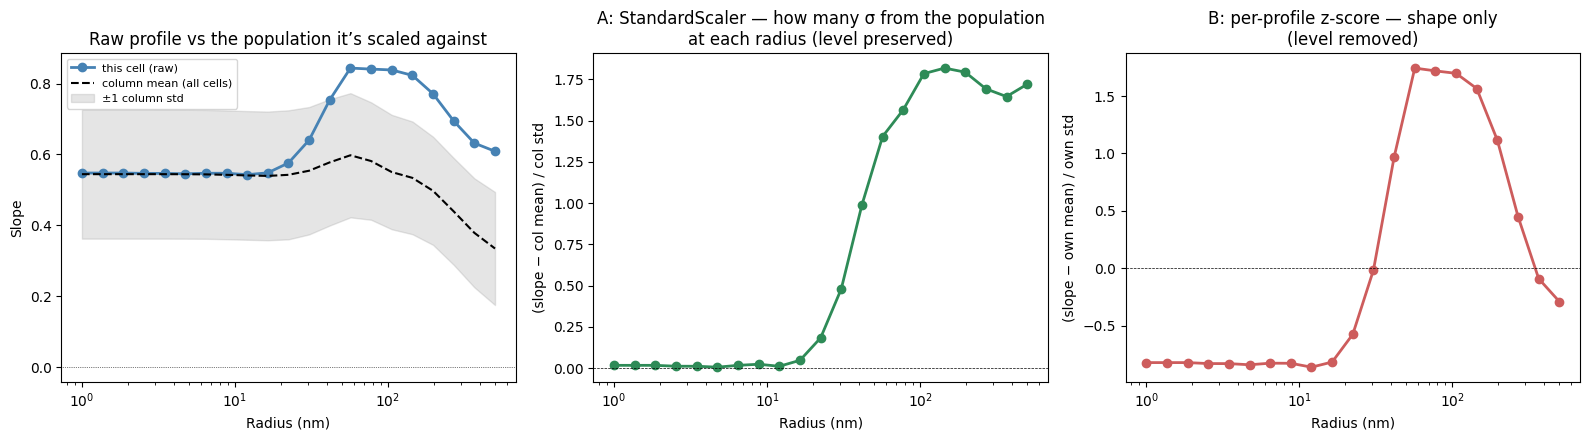

cell index 2555
raw mean across radius:        0.642
scaledA mean across radius:    0.727   (NOT 0 — level preserved)
scaledB mean across radius:    3.384e-16  (≈0 — level removed)


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# pick one example cell (change the index to inspect a different profile)
idx = 2555   # any row in vals_valid

raw_profile    = vals_valid[idx]      # original slope
scaledA_profile = vals_scaledA[idx]   # after StandardScaler (column-wise)
scaledB_profile = vals_scaledB[idx]   # after per-profile z-score (row-wise), for contrast

# the column statistics StandardScaler used (computed across ALL cells)
col_mean = scaler.mean_
col_std  = np.sqrt(scaler.var_)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── Panel 1: raw profile + the column mean±std band it sits in ──
axes[0].plot(radius, raw_profile, 'o-', color='steelblue', lw=2, label='this cell (raw)')
axes[0].plot(radius, col_mean, color='black', lw=1.5, ls='--', label='column mean (all cells)')
axes[0].fill_between(radius, col_mean - col_std, col_mean + col_std,
                     color='gray', alpha=0.2, label='±1 column std')
axes[0].set_xscale('log'); axes[0].axhline(0, color='k', lw=0.5, ls=':')
axes[0].set_xlabel('Radius (nm)'); axes[0].set_ylabel('Slope')
axes[0].set_title('Raw profile vs the population it’s scaled against')
axes[0].legend(fontsize=8)

# ── Panel 2: after StandardScaler (method A) ───────────────────
axes[1].plot(radius, scaledA_profile, 'o-', color='seagreen', lw=2)
axes[1].set_xscale('log'); axes[1].axhline(0, color='k', lw=0.5, ls='--')
axes[1].set_xlabel('Radius (nm)'); axes[1].set_ylabel('(slope − col mean) / col std')
axes[1].set_title('A: StandardScaler — how many σ from the population\nat each radius (level preserved)')

# ── Panel 3: per-profile z-score (method B), for contrast ──────
axes[2].plot(radius, scaledB_profile, 'o-', color='indianred', lw=2)
axes[2].set_xscale('log'); axes[2].axhline(0, color='k', lw=0.5, ls='--')
axes[2].set_xlabel('Radius (nm)'); axes[2].set_ylabel('(slope − own mean) / own std')
axes[2].set_title('B: per-profile z-score — shape only\n(level removed)')

plt.tight_layout()
plt.show()

# numbers for this cell
print(f"cell index {idx}")
print(f"raw mean across radius:        {raw_profile.mean():.3f}")
print(f"scaledA mean across radius:    {scaledA_profile.mean():.3f}   (NOT 0 — level preserved)")
print(f"scaledB mean across radius:    {scaledB_profile.mean():.3e}  (≈0 — level removed)")

Transition matrix — how many profiles stay vs move between the two methods' clusters.

In [9]:
import numpy as np

# transition counts: rows = method A cluster, cols = method B cluster (aligned labels)
trans = np.zeros((k, k), dtype=int)
for a in range(k):
    for b in range(k):
        trans[a, b] = np.sum((labelsA == a) & (labelsB_aligned == b))

print("rows = A cluster, cols = B cluster (aligned)")
print("diagonal = stayed, off-diagonal = moved\n")
print("      " + "".join(f"B{b:>7}" for b in range(k)))
for a in range(k):
    print(f"A{a}  " + "".join(f"{trans[a,b]:>8,}" for b in range(k)))

rows = A cluster, cols = B cluster (aligned)
diagonal = stayed, off-diagonal = moved

      B      0B      1B      2B      3
A0       748   1,065   1,020      87
A1       651   1,948   1,307     680
A2     1,176   1,204   2,008     859
A3       110      19      38     344


Profiles that stayed vs the largest A→B movers, drawn as raw slope curves.

Largest moves (A->B): [('A1->B2', np.int64(1307)), ('A2->B1', np.int64(1204)), ('A2->B0', np.int64(1176))]


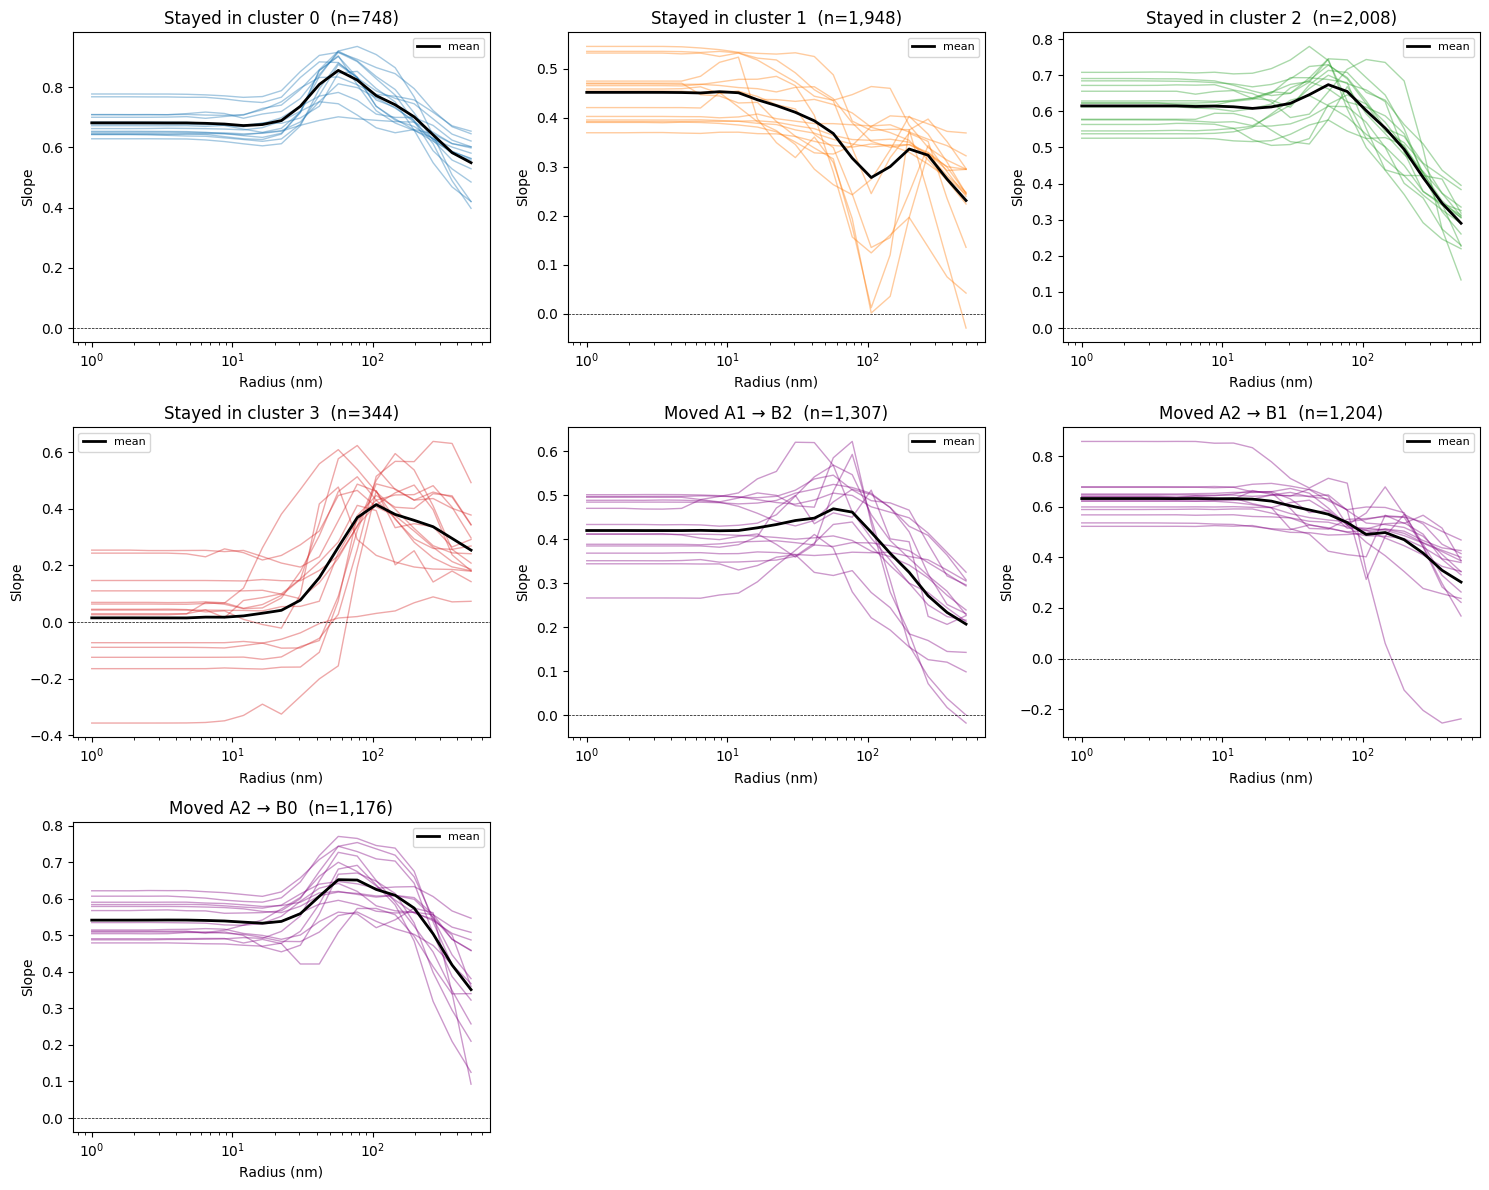

In [10]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
N_SHOW = 15   # profiles drawn per group

def pick(mask, n=N_SHOW):
    """random sample of row-indices (into vals_valid) where mask is True"""
    idx = np.flatnonzero(mask)
    if len(idx) == 0:
        return idx
    return rng.choice(idx, size=min(n, len(idx)), replace=False)

# ── identify the biggest off-diagonal transitions to feature ──
off = [(a, b, trans[a, b]) for a in range(k) for b in range(k) if a != b]
off.sort(key=lambda t: -t[2])
top_moves = off[:3]            # three largest A->B flows
print("Largest moves (A->B):", [(f"A{a}->B{b}", n) for a, b, n in top_moves])

cmap = plt.get_cmap('tab10')
n_panels = k + len(top_moves)
ncols = 3
nrows = int(np.ceil(n_panels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

# ── stayers: same cluster in both methods ─────────────────────
for c in range(k):
    ax = axes[c]
    sel = pick((labelsA == c) & (labelsB_aligned == c))
    for i in sel:
        ax.plot(radius, vals_valid[i], color=cmap(c), alpha=0.4, lw=1)
    if len(sel):
        ax.plot(radius, vals_valid[sel].mean(0), color='black', lw=2, label='mean')
    ax.set_xscale('log'); ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_title(f'Stayed in cluster {c}  (n={trans[c,c]:,})')
    ax.set_xlabel('Radius (nm)'); ax.set_ylabel('Slope'); ax.legend(fontsize=8)

# ── movers: largest A->B transitions ──────────────────────────
for j, (a, b, n) in enumerate(top_moves):
    ax = axes[k + j]
    sel = pick((labelsA == a) & (labelsB_aligned == b))
    for i in sel:
        ax.plot(radius, vals_valid[i], color='purple', alpha=0.4, lw=1)
    if len(sel):
        ax.plot(radius, vals_valid[sel].mean(0), color='black', lw=2, label='mean')
    ax.set_xscale('log'); ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_title(f'Moved A{a} → B{b}  (n={n:,})')
    ax.set_xlabel('Radius (nm)'); ax.set_ylabel('Slope'); ax.legend(fontsize=8)

# hide any unused panels
for ax in axes[n_panels:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

The biggest off-diagonal flows shown in both axes: raw slope (what Method A saw) on top,
z-scored shape (what Method B saw) on the bottom.

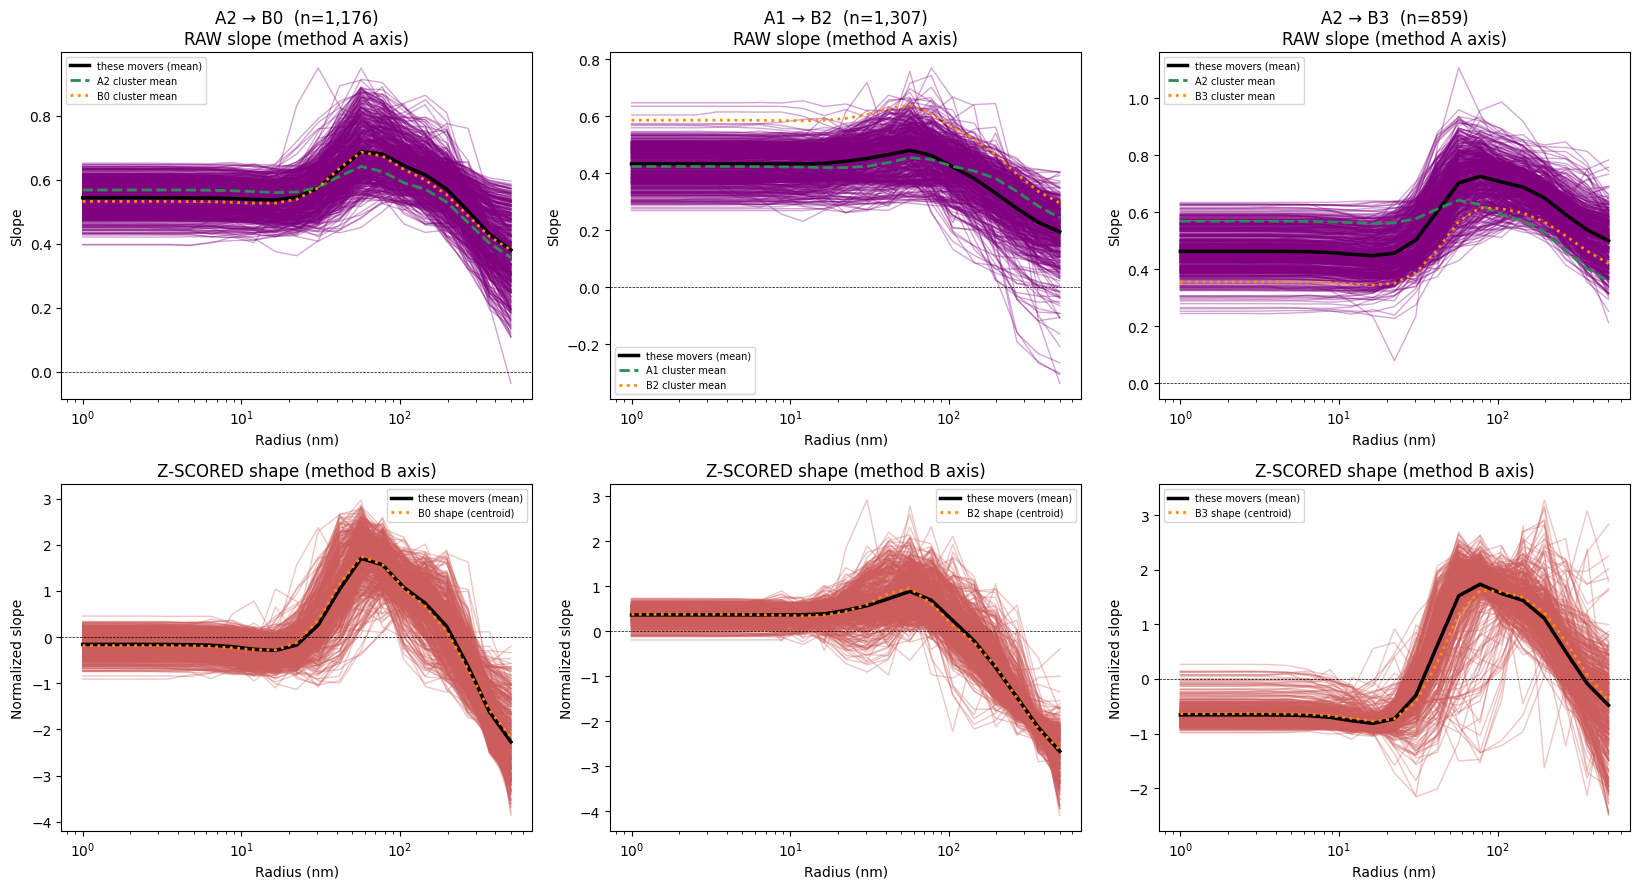

In [11]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(0)
N_SHOW = 500

moves = [(2, 0), (1, 2), (2, 3)]   # (A cluster, B cluster) off-diagonal flows to inspect

def pick(mask, n=N_SHOW):
    idx = np.flatnonzero(mask)
    return rng.choice(idx, size=min(n, len(idx)), replace=False) if len(idx) else idx

# B-cluster mean shapes (z-scored), for reference overlay
B_mean_shape = {b: vals_scaledB[labelsB_aligned == b].mean(0) for b in range(k)}
# B-cluster mean raw level, for reference overlay
B_mean_raw   = {b: vals_valid[labelsB_aligned == b].mean(0) for b in range(k)}

ncols = len(moves)
fig, axes = plt.subplots(2, ncols, figsize=(5.5 * ncols, 9), squeeze=False)

for j, (a, b) in enumerate(moves):
    sel = pick((labelsA == a) & (labelsB_aligned == b))
    n = np.sum((labelsA == a) & (labelsB_aligned == b))

    # ── top row: RAW slope (what method A saw — level matters) ──
    axR = axes[0, j]
    for i in sel:
        axR.plot(radius, vals_valid[i], color='purple', alpha=0.35, lw=1)
    if len(sel):
        axR.plot(radius, vals_valid[sel].mean(0), color='black', lw=2.5,
                 label=f'these movers (mean)')
    # reference: mean raw level of the A-source and B-dest clusters
    axR.plot(radius, vals_valid[labelsA == a].mean(0), color='seagreen',
             lw=2, ls='--', label=f'A{a} cluster mean')
    axR.plot(radius, B_mean_raw[b], color='darkorange',
             lw=2, ls=':', label=f'B{b} cluster mean')
    axR.set_xscale('log'); axR.axhline(0, color='k', lw=0.5, ls='--')
    axR.set_title(f'A{a} → B{b}  (n={n:,})\nRAW slope (method A axis)')
    axR.set_xlabel('Radius (nm)'); axR.set_ylabel('Slope'); axR.legend(fontsize=7)

    # ── bottom row: Z-SCORED (what method B saw — shape only) ──
    axZ = axes[1, j]
    for i in sel:
        axZ.plot(radius, vals_scaledB[i], color='indianred', alpha=0.35, lw=1)
    if len(sel):
        axZ.plot(radius, vals_scaledB[sel].mean(0), color='black', lw=2.5,
                 label='these movers (mean)')
    # reference: shape of the B-dest cluster they were assigned to
    axZ.plot(radius, B_mean_shape[b], color='darkorange', lw=2, ls=':',
             label=f'B{b} shape (centroid)')
    axZ.set_xscale('log'); axZ.axhline(0, color='k', lw=0.5, ls='--')
    axZ.set_title(f'Z-SCORED shape (method B axis)')
    axZ.set_xlabel('Radius (nm)'); axZ.set_ylabel('Normalized slope'); axZ.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 4. Optimal CCN activation diameter per cluster

For each cluster (using **Method A** labels), find the diameter that best marks the CCN
activation onset — the susceptibility peak / plateau edge — by three methods:

- **Argmax:** diameter of maximum mean slope (simplest).
- **Gradient-threshold:** smooth the profile, find where the normalized gradient first
  drops below a threshold (plateau edge).
- **Kneedle:** Kneedle knee-detection on the smoothed profile in log-diameter space.

Final parameters (chosen from an earlier sample grid-search): gradient σ=1.5, drop=0.05;
Kneedle σ=2.0, S=1.0.

In [12]:
# Use Method A's clustering for the optimal-diameter analysis.
labels_valid = labelsA
k = 4
diameter = radius * 2   # nm (radius is in nm; diameter = 2*radius)


In [13]:
# --- Plateau-edge detectors (final parameters) ---
def find_plateau_edge(profile, diameter, sigma=2.0, drop_threshold=0.05):
    """Right edge of the initial plateau: where the smoothed, range-normalized
    gradient first drops below -drop_threshold."""
    smooth = gaussian_filter1d(profile, sigma=sigma)
    gradient = np.gradient(smooth)
    profile_range = smooth.max() - smooth.min()
    if profile_range == 0:
        return np.nan
    norm_gradient = gradient / profile_range
    decline_indices = np.where(norm_gradient < -drop_threshold)[0]
    if len(decline_indices) == 0:
        return diameter[-1]
    edge_idx = max(0, decline_indices[0] - 1)
    return diameter[edge_idx]

def find_plateau_edge_kneedle(profile, diameter, sigma=2.0, S=1.0):
    """Knee of the smoothed profile in log-diameter space (Kneedle)."""
    smooth = gaussian_filter1d(profile, sigma=sigma)
    kl = KneeLocator(x=np.log10(diameter), y=smooth, S=S,
                     curve='concave', direction='decreasing',
                     interp_method='interp1d', online=True)
    return np.nan if kl.knee is None else 10 ** kl.knee


In [14]:
def agreement(opt1, opt2):
    """Compare two arrays of optimal diameters in log space."""
    valid = np.isfinite(opt1) & np.isfinite(opt2)
    log_diff = np.log10(opt1[valid]) - np.log10(opt2[valid])
    return {
        'mean_abs_log_diff': np.abs(log_diff).mean(),
        'median_abs_log_diff': np.median(np.abs(log_diff)),
        'correlation': np.corrcoef(np.log10(opt1[valid]), np.log10(opt2[valid]))[0, 1],
        'nan_frac_grad': (~np.isfinite(opt1)).mean(),
        'nan_frac_knee': (~np.isfinite(opt2)).mean(),
        'n_valid': valid.sum(),
    }


Per-cell optimal diameter across the whole grid, gradient vs Kneedle, with their agreement.

Full dataset agreement (n=13,264):
  Mean |dlog10|:   0.0625
  Median |dlog10|: 0.0000
  Correlation:     0.9421


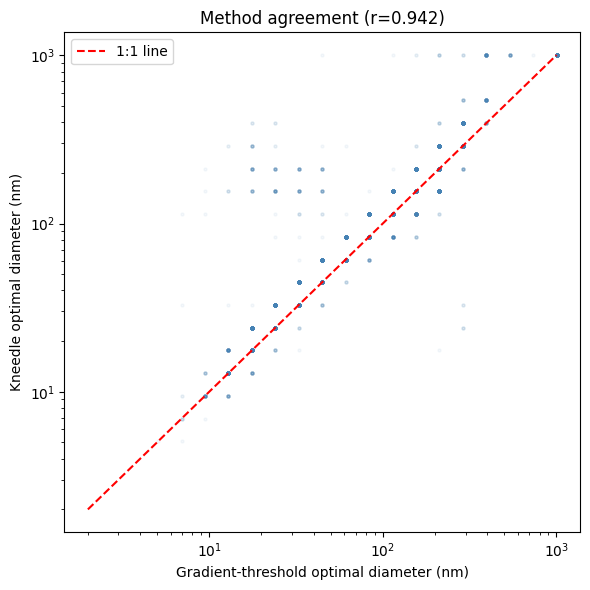

In [15]:
# --- Per-cell optimal diameter (full grid), both plateau methods ---
opt_grad = np.array([find_plateau_edge(vals_valid[i], diameter, sigma=1.5, drop_threshold=0.05)
                     for i in range(len(vals_valid))])
opt_knee = np.array([find_plateau_edge_kneedle(vals_valid[i], diameter, sigma=2.0, S=1.0)
                     for i in range(len(vals_valid))])

metrics = agreement(opt_grad, opt_knee)
print(f'Full dataset agreement (n={len(vals_valid):,}):')
print(f"  Mean |dlog10|:   {metrics['mean_abs_log_diff']:.4f}")
print(f"  Median |dlog10|: {metrics['median_abs_log_diff']:.4f}")
print(f"  Correlation:     {metrics['correlation']:.4f}")

valid_m = np.isfinite(opt_grad) & np.isfinite(opt_knee)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(opt_grad[valid_m], opt_knee[valid_m], alpha=0.05, s=5, color='steelblue')
ax.plot([diameter.min(), diameter.max()], [diameter.min(), diameter.max()],
        'r--', linewidth=1.5, label='1:1 line')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Gradient-threshold optimal diameter (nm)')
ax.set_ylabel('Kneedle optimal diameter (nm)')
ax.set_title(f"Method agreement (r={metrics['correlation']:.3f})")
ax.legend()
plt.tight_layout()
plt.show()


Cluster mean profiles with all three optimal-diameter estimates marked
(○ argmax, △ gradient-threshold, □ Kneedle).

Optimal diameter (argmax vs plateau-edge methods):

  Cluster 0 (n=2,920):
    Argmax:   83.4 nm  (slope=0.8009)
    Gradient: 83.4 nm  (slope=0.8009)
    Kneedle:  83.4 nm  (slope=0.8009)

  Cluster 1 (n=4,586):
    Argmax:   113.8 nm  (slope=0.4543)
    Gradient: 113.8 nm  (slope=0.4543)
    Kneedle:  155.2 nm  (slope=0.4476)

  Cluster 2 (n=5,247):
    Argmax:   113.8 nm  (slope=0.6422)
    Gradient: 113.8 nm  (slope=0.6422)
    Kneedle:  155.2 nm  (slope=0.6265)

  Cluster 3 (n=511):
    Argmax:   155.2 nm  (slope=0.3770)
    Gradient: 211.9 nm  (slope=0.3660)
    Kneedle:  289.1 nm  (slope=0.3392)

  Overall (n=13,264):
    Argmax:   113.8 nm
    Gradient: 113.8 nm
    Kneedle:  155.2 nm


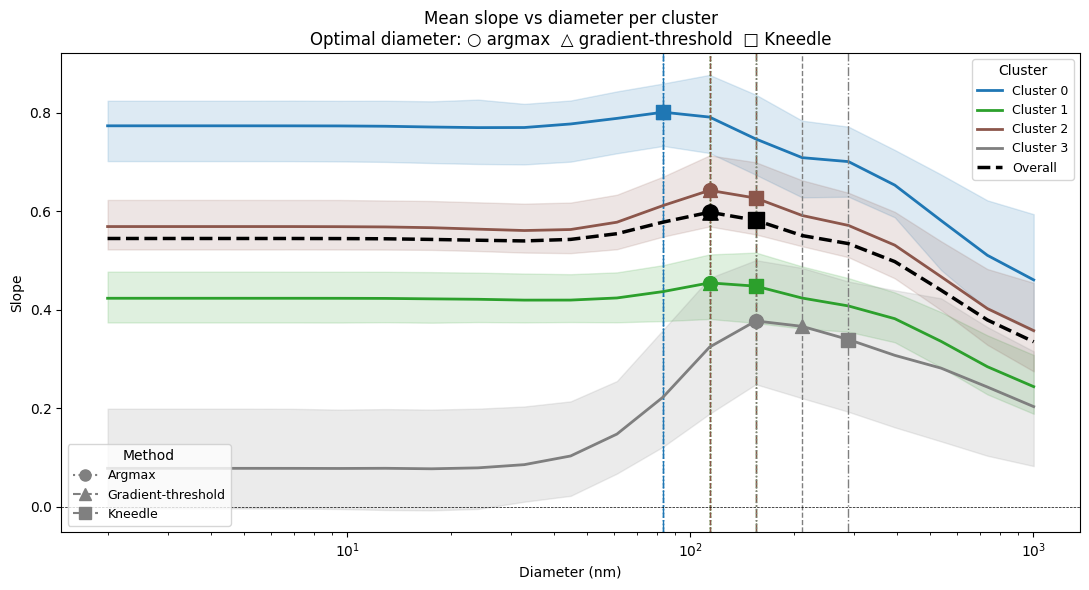

In [16]:
print('Optimal diameter (argmax vs plateau-edge methods):\n')
fig, ax = plt.subplots(figsize=(11, 6))

for i in range(k):
    cluster_vals = vals_valid[labels_valid == i]
    mean = cluster_vals.mean(axis=0)
    q25  = np.percentile(cluster_vals, 25, axis=0)
    q75  = np.percentile(cluster_vals, 75, axis=0)

    argmax_idx  = np.argmax(mean)
    argmax_diam = diameter[argmax_idx]; argmax_slope = mean[argmax_idx]
    grad_diam   = find_plateau_edge(mean, diameter, sigma=1.5, drop_threshold=0.05)
    grad_slope  = mean[np.argmin(np.abs(diameter - grad_diam))]
    knee_diam   = find_plateau_edge_kneedle(mean, diameter, sigma=2.0, S=1.0)
    knee_slope  = mean[np.argmin(np.abs(diameter - knee_diam))] if np.isfinite(knee_diam) else np.nan

    print(f'  Cluster {i} (n={(labels_valid==i).sum():,}):')
    print(f'    Argmax:   {argmax_diam:.1f} nm  (slope={argmax_slope:.4f})')
    print(f'    Gradient: {grad_diam:.1f} nm  (slope={grad_slope:.4f})')
    print(f'    Kneedle:  {knee_diam:.1f} nm  (slope={knee_slope:.4f})\n')

    color = mpl.colormaps['tab10'](i / k)
    ax.plot(diameter, mean, color=color, linewidth=2, label=f'Cluster {i}')
    ax.fill_between(diameter, q25, q75, color=color, alpha=0.15)
    ax.scatter(argmax_diam, argmax_slope, color=color, s=100, zorder=5, marker='o')
    ax.axvline(argmax_diam, color=color, linewidth=1, linestyle=':')
    ax.scatter(grad_diam, grad_slope, color=color, s=100, zorder=5, marker='^')
    ax.axvline(grad_diam, color=color, linewidth=1, linestyle='--')
    if np.isfinite(knee_diam):
        ax.scatter(knee_diam, knee_slope, color=color, s=100, zorder=5, marker='s')
        ax.axvline(knee_diam, color=color, linewidth=1, linestyle='-.')

# Overall mean profile
overall_mean = vals_valid.mean(axis=0)
overall_argmax_diam = diameter[np.argmax(overall_mean)]
overall_grad_diam   = find_plateau_edge(overall_mean, diameter, sigma=1.5, drop_threshold=0.05)
overall_knee_diam   = find_plateau_edge_kneedle(overall_mean, diameter, sigma=2.0, S=1.0)
print(f'  Overall (n={len(vals_valid):,}):')
print(f'    Argmax:   {overall_argmax_diam:.1f} nm')
print(f'    Gradient: {overall_grad_diam:.1f} nm')
print(f'    Kneedle:  {overall_knee_diam:.1f} nm')

ax.plot(diameter, overall_mean, color='black', linewidth=2.5, linestyle='--', label='Overall')
ax.scatter(overall_argmax_diam, overall_mean[np.argmax(overall_mean)], color='black', s=120, marker='o', zorder=6)
ax.scatter(overall_grad_diam, overall_mean[np.argmin(np.abs(diameter - overall_grad_diam))], color='black', s=120, marker='^', zorder=6)
if np.isfinite(overall_knee_diam):
    ax.scatter(overall_knee_diam, overall_mean[np.argmin(np.abs(diameter - overall_knee_diam))], color='black', s=120, marker='s', zorder=6)

method_legend = [
    Line2D([0], [0], marker='o', color='gray', linestyle=':', markersize=8, label='Argmax'),
    Line2D([0], [0], marker='^', color='gray', linestyle='--', markersize=8, label='Gradient-threshold'),
    Line2D([0], [0], marker='s', color='gray', linestyle='-.', markersize=8, label='Kneedle'),
]
legend1 = ax.legend(handles=method_legend, loc='lower left', fontsize=9, title='Method')
ax.add_artist(legend1)
ax.legend(loc='upper right', fontsize=9, title='Cluster')
ax.set_xscale('log')
ax.set_xlabel('Diameter (nm)')
ax.set_ylabel('Slope')
ax.set_title('Mean slope vs diameter per cluster\nOptimal diameter: ○ argmax  △ gradient-threshold  □ Kneedle')
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()


Map of the per-cell plateau-edge (gradient) optimal diameter, and its distribution.

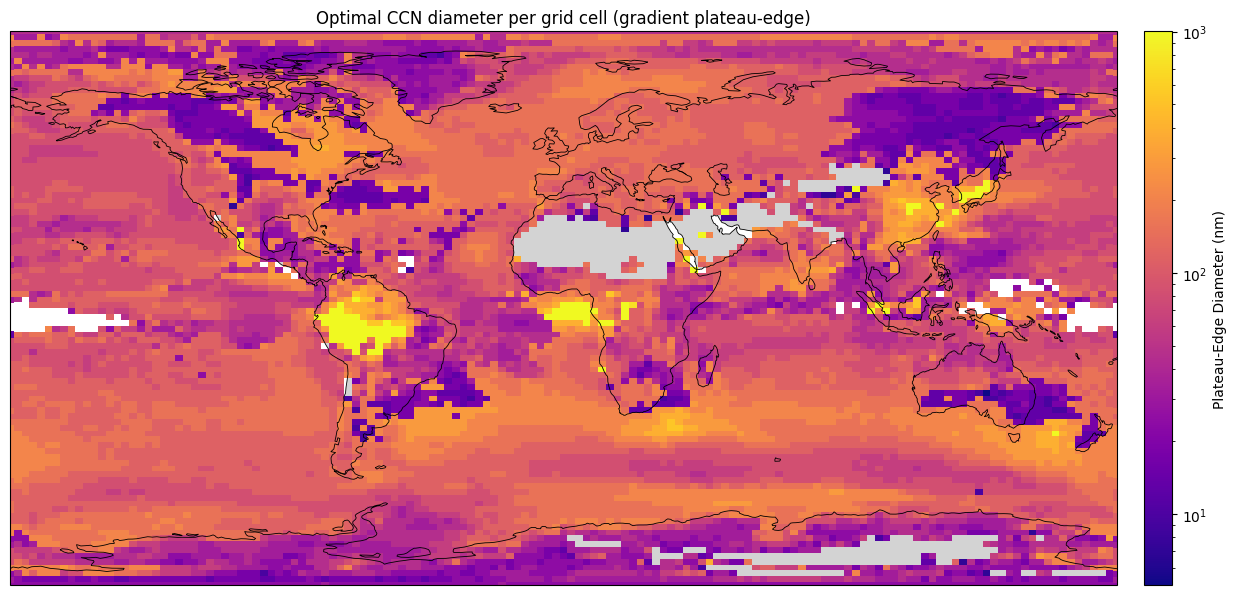

Min / Mean / Median / Max optimal diameter: 5.1 / 115.6 / 113.8 / 1002.4 nm


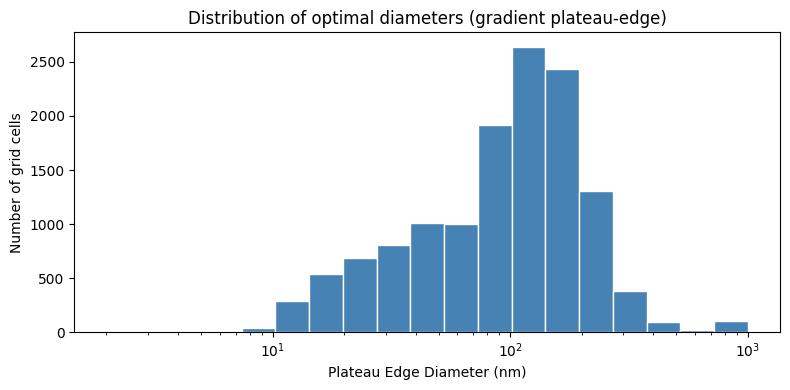

In [17]:
# --- Map + histogram of the gradient-method optimal diameter ---
# Rebuild the full (lat, lon) grid from the valid-row results.
opt_full = np.full(vals.shape[0], np.nan)
opt_full[valid] = opt_grad
opt_2d = opt_full.reshape(len(lat), len(lon))

fig, ax = plt.subplots(figsize=(14, 6), subplot_kw={'projection': ccrs.PlateCarree()})
cmap = plt.cm.plasma.copy(); cmap.set_bad(alpha=0)
im = ax.pcolormesh(lon, lat, np.ma.masked_invalid(opt_2d), cmap=cmap,
                   norm=mcolors.LogNorm(vmin=np.nanmin(opt_2d), vmax=np.nanmax(opt_2d)),
                   transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
cb.set_label('Plateau-Edge Diameter (nm)')
ax.set_title('Optimal CCN diameter per grid cell (gradient plateau-edge)')
plt.tight_layout()
plt.show()

print(f'Min / Mean / Median / Max optimal diameter: '
      f'{np.nanmin(opt_2d):.1f} / {np.nanmean(opt_2d):.1f} / '
      f'{np.nanmedian(opt_2d):.1f} / {np.nanmax(opt_2d):.1f} nm')

fig, ax = plt.subplots(figsize=(8, 4))
log_bins = np.logspace(np.log10(diameter.min()), np.log10(diameter.max()), 20)
ax.hist(opt_grad[np.isfinite(opt_grad)], bins=log_bins, color='steelblue', edgecolor='white')
ax.set_xscale('log')
ax.set_xlabel('Plateau Edge Diameter (nm)')
ax.set_ylabel('Number of grid cells')
ax.set_title('Distribution of optimal diameters (gradient plateau-edge)')
plt.tight_layout()
plt.show()
